In [1]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.nn.utils.rnn import pad_sequence
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
# Device configuration
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: {device} (CUDA is available)")
else:
    device = torch.device("cpu")
    print(f"Using device: {device} (CUDA is not available, falling back to CPU)")

Using device: cpu (CUDA is not available, falling back to CPU)


In [3]:
# Load and prepare data
data = pd.read_csv("ner_dataset.csv", encoding="latin1").ffill()
words = list(data["Word"].unique())
tags = list(data["Tag"].unique())

if "ENDPAD" not in words:
    words.append("ENDPAD")

word2idx = {w: i + 1 for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}
idx2tag = {i: t for t, i in tag2idx.items()}


In [4]:
data.head(50)

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O
5,Sentence: 1,through,IN,O
6,Sentence: 1,London,NNP,B-geo
7,Sentence: 1,to,TO,O
8,Sentence: 1,protest,VB,O
9,Sentence: 1,the,DT,O


In [5]:
print("Unique words in corpus:", data['Word'].nunique())
print("Unique tags in corpus:", data['Tag'].nunique())

Unique words in corpus: 9563
Unique tags in corpus: 17


In [6]:
print("Unique tags are:", tags)

Unique tags are: ['O', 'B-geo', 'B-gpe', 'B-per', 'I-geo', 'B-org', 'I-org', 'B-tim', 'B-art', 'I-art', 'I-per', 'I-gpe', 'I-tim', 'B-nat', 'B-eve', 'I-eve', 'I-nat']


In [7]:
# Group words by sentences
class SentenceGetter:
    def __init__(self, data):
        self.grouped = data.groupby("Sentence #", group_keys=False).apply(
            lambda s: [(w, t) for w, t in zip(s["Word"], s["Tag"])]
        )
        self.sentences = list(self.grouped)

getter = SentenceGetter(data)
sentences = getter.sentences

In [8]:
sentences[35]

[('On', 'O'),
 ('Friday', 'B-tim'),
 (',', 'O'),
 ('five', 'O'),
 ('soldiers', 'O'),
 ('were', 'O'),
 ('killed', 'O'),
 ('when', 'O'),
 ('dozens', 'O'),
 ('of', 'O'),
 ('militants', 'O'),
 ('stormed', 'O'),
 ('a', 'O'),
 ('military', 'O'),
 ('checkpoint', 'O'),
 ('in', 'O'),
 ('Orakzai', 'B-geo'),
 ('.', 'O')]

In [9]:
# Encode sentences
X = [[word2idx[w] for w, t in s] for s in sentences]
y = [[tag2idx[t] for w, t in s] for s in sentences]

In [10]:
word2idx

{'Thousands': 1,
 'of': 2,
 'demonstrators': 3,
 'have': 4,
 'marched': 5,
 'through': 6,
 'London': 7,
 'to': 8,
 'protest': 9,
 'the': 10,
 'war': 11,
 'in': 12,
 'Iraq': 13,
 'and': 14,
 'demand': 15,
 'withdrawal': 16,
 'British': 17,
 'troops': 18,
 'from': 19,
 'that': 20,
 'country': 21,
 '.': 22,
 'Families': 23,
 'soldiers': 24,
 'killed': 25,
 'conflict': 26,
 'joined': 27,
 'protesters': 28,
 'who': 29,
 'carried': 30,
 'banners': 31,
 'with': 32,
 'such': 33,
 'slogans': 34,
 'as': 35,
 '"': 36,
 'Bush': 37,
 'Number': 38,
 'One': 39,
 'Terrorist': 40,
 'Stop': 41,
 'Bombings': 42,
 'They': 43,
 'Houses': 44,
 'Parliament': 45,
 'a': 46,
 'rally': 47,
 'Hyde': 48,
 'Park': 49,
 'Police': 50,
 'put': 51,
 'number': 52,
 'marchers': 53,
 'at': 54,
 '10,000': 55,
 'while': 56,
 'organizers': 57,
 'claimed': 58,
 'it': 59,
 'was': 60,
 '1,00,000': 61,
 'The': 62,
 'comes': 63,
 'on': 64,
 'eve': 65,
 'annual': 66,
 'conference': 67,
 'Britain': 68,
 "'s": 69,
 'ruling': 70,
 'L

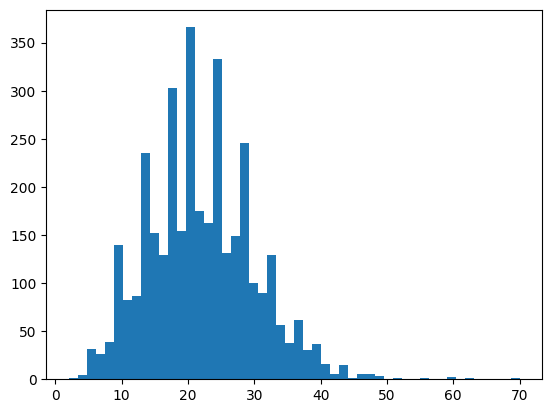

In [11]:
plt.hist([len(s) for s in sentences], bins=50)
plt.show()

In [12]:
# Pad sequences
max_len = 50
X_pad = pad_sequence([torch.tensor(seq) for seq in X], batch_first=True, padding_value=word2idx["ENDPAD"])
y_pad = pad_sequence([torch.tensor(seq) for seq in y], batch_first=True, padding_value=tag2idx["O"])
X_pad = X_pad[:, :max_len]
y_pad = y_pad[:, :max_len]

In [13]:
X_pad[0]

tensor([   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,   11,   12,
          13,   14,   15,   10,   16,    2,   17,   18,   19,   20,   21,   22,
        9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564,
        9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564,
        9564, 9564])

In [14]:
y_pad[0]

tensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0])

In [15]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_pad, y_pad, test_size=0.2, random_state=1)

In [16]:

# Dataset class
class NERDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "input_ids": self.X[idx],
            "labels": self.y[idx]
        }

train_loader = DataLoader(NERDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(NERDataset(X_test, y_test), batch_size=32)

In [17]:

# Model definition
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags, dropout_prob=0.3):
        super(BiLSTMTagger, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(dropout_prob)
        self.hidden2tag = nn.Linear(hidden_dim * 2, num_tags) # *2 for bidirectional

    def forward(self, input_ids):
        embeddings = self.embedding(input_ids)
        lstm_out, _ = self.lstm(embeddings)
        lstm_out = self.dropout(lstm_out)
        tag_space = self.hidden2tag(lstm_out)
        return tag_space

vocab_size = len(word2idx) + 1 # +1 for padding index 0, as word2idx starts from 1
embedding_dim = 100
hidden_dim = 256
num_tags = len(tag2idx)
dropout_prob = 0.3

model = BiLSTMTagger(vocab_size, embedding_dim, hidden_dim, num_tags, dropout_prob).to(device)


In [18]:
loss_fn = nn.CrossEntropyLoss(ignore_index=tag2idx["O"])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [19]:

# Training and Evaluation Functions
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=3, device=None, idx2tag=None):
    train_losses = []
    val_losses = []

    def _train_epoch(model, loader, loss_fn, optimizer, current_device):
        model.train()
        total_loss = 0
        for batch in loader:
            input_ids = batch["input_ids"].to(current_device)
            labels = batch["labels"].to(current_device)

            optimizer.zero_grad()
            outputs = model(input_ids)

            outputs = outputs.view(-1, outputs.shape[-1])
            labels = labels.view(-1)

            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    def _evaluate_epoch(model, loader, loss_fn, current_device, current_idx2tag):
        model.eval()
        total_loss = 0
        all_predictions = []
        all_true_labels = []
        with torch.no_grad():
            for batch in loader:
                input_ids = batch["input_ids"].to(current_device)
                labels = batch["labels"].to(current_device)

                outputs = model(input_ids)

                outputs_reshaped = outputs.view(-1, outputs.shape[-1])
                labels_reshaped = labels.view(-1)
                loss = loss_fn(outputs_reshaped, labels_reshaped)
                total_loss += loss.item()

                predictions = torch.argmax(outputs, dim=-1)

                o_tag_idx = tag2idx["O"] # Assuming tag2idx is globally available and correct
                all_predictions.extend(predictions.view(-1).cpu().numpy())
                all_true_labels.extend(labels.view(-1).cpu().numpy())

        filtered_predictions = [current_idx2tag[p] for p, l in zip(all_predictions, all_true_labels) if l != o_tag_idx]
        filtered_true_labels = [current_idx2tag[l] for p, l in zip(all_predictions, all_true_labels) if l != o_tag_idx]

        report = classification_report(filtered_true_labels, filtered_predictions, zero_division=0)
        return total_loss / len(loader), report

    for epoch in range(epochs):
        current_train_loss = _train_epoch(model, train_loader, loss_fn, optimizer, device)
        current_val_loss, report = _evaluate_epoch(model, test_loader, loss_fn, device, idx2tag)

        train_losses.append(current_train_loss)
        val_losses.append(current_val_loss)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {current_train_loss:.4f}, Test Loss: {current_val_loss:.4f}")
        print("Classification Report for Test Set:\n", report)

    return train_losses, val_losses

# Training loop call (using global num_epochs, device, idx2tag)
# Ensure num_epochs, device, idx2tag are defined before executing this cell
num_epochs = 5
trained_losses, validated_losses = train_model(model, train_loader, test_loader, loss_fn, optimizer, num_epochs, device, idx2tag)


Epoch 1/5
Train Loss: 1.8514, Test Loss: 1.4484
Classification Report for Test Set:
               precision    recall  f1-score   support

       B-art       0.00      0.00      0.00        13
       B-eve       0.00      0.00      0.00        14
       B-geo       0.51      0.69      0.59       496
       B-gpe       0.49      0.56      0.53       242
       B-nat       0.00      0.00      0.00         8
       B-org       0.38      0.45      0.41       266
       B-per       0.61      0.52      0.56       281
       B-tim       0.69      0.63      0.66       292
       I-art       0.00      0.00      0.00         4
       I-eve       0.00      0.00      0.00        13
       I-geo       0.83      0.20      0.33        93
       I-gpe       0.00      0.00      0.00         7
       I-nat       0.00      0.00      0.00         4
       I-org       0.46      0.49      0.48       185
       I-per       0.63      0.66      0.65       308
       I-tim       1.00      0.02      0.04       

In [20]:
def evaluate_model(model, test_loader, X_test, y_test):
    model.eval()
    true_tags, pred_tags = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=-1)
            for i in range(len(labels)):
                for j in range(len(labels[i])):
                    if labels[i][j] != tag2idx["O"]:
                        true_tags.append(idx2tag[labels[i][j].item()])
                        pred_tags.append(idx2tag[preds[i][j].item()])


In [22]:
train_losses, val_losses = train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=3, device=device, idx2tag=idx2tag)
evaluate_model(model, test_loader, X_test, y_test)

Epoch 1/3
Train Loss: 0.2411, Test Loss: 1.1460
Classification Report for Test Set:
               precision    recall  f1-score   support

       B-art       0.00      0.00      0.00        13
       B-eve       0.70      0.50      0.58        14
       B-geo       0.66      0.76      0.71       496
       B-gpe       0.60      0.75      0.67       242
       B-nat       1.00      0.12      0.22         8
       B-org       0.64      0.56      0.60       266
       B-per       0.71      0.66      0.68       281
       B-tim       0.83      0.81      0.82       292
       I-art       0.00      0.00      0.00         4
       I-eve       0.88      0.54      0.67        13
       I-geo       0.58      0.59      0.59        93
       I-gpe       0.33      0.29      0.31         7
       I-nat       1.00      0.25      0.40         4
       I-org       0.66      0.60      0.63       185
       I-per       0.79      0.74      0.77       308
       I-tim       0.68      0.65      0.66       

Name:SAKTHIVEL S
Register Number:212223220090


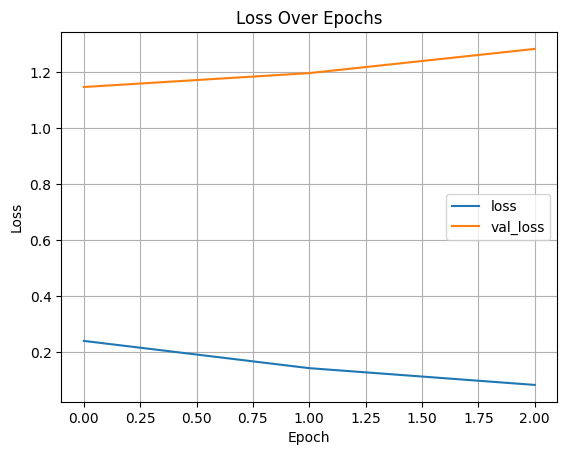

In [24]:
# Plot loss
print('Name:SAKTHIVEL S')
print('Register Number:212223220090')
history_df = pd.DataFrame({"loss": train_losses, "val_loss": val_losses})
history_df.plot(title="Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [25]:
# Inference and prediction
i = 125
model.eval()
sample = X_test[i].unsqueeze(0).to(device)
output = model(sample)
preds = torch.argmax(output, dim=-1).squeeze().cpu().numpy()
true = y_test[i].numpy()

print('Name:                 ')
print('Register Number:     ')
print("{:<15} {:<10} {}\n{}".format("Word", "True", "Pred", "-" * 40))
for w_id, true_tag, pred_tag in zip(X_test[i], y_test[i], preds):
    if w_id.item() != word2idx["ENDPAD"]:
        word = words[w_id.item() - 1]
        true_label = tags[true_tag.item()]
        pred_label = tags[pred_tag]
        print(f"{word:<15} {true_label:<10} {pred_label}")


Name:                 
Register Number:     
Word            True       Pred
----------------------------------------
A               O          B-geo
total           O          B-tim
of              O          I-tim
25              O          B-geo
were            O          I-geo
tried           O          I-geo
in              O          B-tim
absentia        O          B-geo
,               O          I-geo
while           O          B-geo
14              O          B-org
others          O          B-per
have            O          B-per
died            O          B-tim
since           O          B-tim
the             O          B-geo
trial           O          B-tim
began           O          I-tim
in              O          I-tim
1994            B-tim      I-tim
.               O          I-geo
